# DistilBERT

The notebook contains code to show how distilbert was utilized in the study. The dataset was built iteratively, as described in the applications and results section, so the sample shown here may not exactly match the final numbers reported in the thesis.

In [ ]:
!pip install transformers datasets torch tqdm scikit-learn
!pip install transformers[torch]
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

import evaluate
import numpy as np

import os

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
np.random.seed(13)
torch.manual_seed(13)
torch.cuda.manual_seed_all(13)

<Axes: xlabel='my_label'>

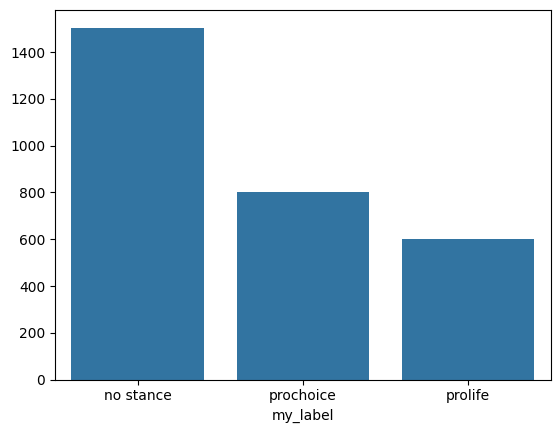

In [3]:
df = pd.read_csv('labeled_data_h.csv')
df = df[df['my_label'] != 'unclear']

sns.barplot(x=df['my_label'].value_counts().index,
            y=df['my_label'].value_counts().values)

In [4]:
df = df[['body', 'my_label']]

label_map = {"no stance": 0, "prochoice": 1, "prolife": 2}
df['label'] = df['my_label'].map(label_map)

print('my_labels:', df['my_label'].unique())
print('label:', df['label'].unique())

my_labels: ['prochoice' 'prolife' 'no stance']
label: [1 2 0]


<ipython-input-4-474e7140626a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['my_label'].map(label_map)


In [5]:
# token
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# model
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",
                                                            num_labels=3,
                                                            id2label = {"no stance": 0, "prochoice": 1, "prolife": 2},
                                                            label2id = label_map)
model.config.hidden_dropout_prob = 0.3
model.config.attention_probs_dropout_prob = 0.3



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# trainable params - only want to train top layers

# freeze base model params
for name, param in model.base_model.named_parameters():
  param.requires_grad = False

  # if "classifier" in name or "transformer.layer.5" in name:
  #   param.requires_grad = True

  if "classifier" in name or "transformer.layer.4" in name or "transformer.layer.5" in name:
    param.requires_grad = True

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["body"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42
)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512)

train_labels = torch.tensor(train_labels, dtype=torch.long)
test_labels = torch.tensor(test_labels, dtype=torch.long)
train_labels = train_labels.tolist()
test_labels = test_labels.tolist()

train_dataset = Dataset.from_dict({**train_encodings, "label": train_labels})
test_dataset = Dataset.from_dict({**test_encodings, "label": test_labels})

In [ ]:
# padding
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [10]:
accuracy = evaluate.load('accuracy')
auc_score = evaluate.load('roc_auc')
f1 = evaluate.load("f1")

In [11]:
def compute_metrics(eval_pred):
  pred, labels = eval_pred

  prob = np.exp(pred) / np.exp(pred).sum(-1, keepdims=True)

  pos_class_prob = prob[:, 1]

  predicted_classes = np.argmax(pred, axis = 1)
  acc = (accuracy.compute(predictions=predicted_classes, references=labels))

  f1_metric = evaluate.load('f1')
  f1 = f1_metric.compute(predictions = predicted_classes, references=labels, average='macro') # 'lables' was misspelled

  return {
      "accuracy": acc["accuracy"],
      "f1": f1['f1']
  }

In [12]:
# hyper params
lr = 2e-5
batch_size = 32
num_epochs = 7

training_args = TrainingArguments(
    output_dir="abortion_attitudes_teacher",
    learning_rate = lr,
    report_to = "none",
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    num_train_epochs = num_epochs,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    weight_decay=0.01,
    load_best_model_at_end=True,
)

increasing the learning rate to 1e-5 \helping with everything\

lr increase + 16 batch size gave best model preformance so far, but started overfitting after 3 epochs

decreasing weight decay also boosted, but same thing tapped out after 3 epochs



In [ ]:
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "offline"
os.environ['WANDB_MODE'] = 'disabled'


In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,

)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.721725,0.683849,0.595491
2,No log,0.582084,0.757732,0.730121
3,No log,0.534326,0.774914,0.758087
4,No log,0.526138,0.781787,0.769492
5,No log,0.515955,0.790378,0.766191
6,No log,0.518480,0.792096,0.775632
7,0.559100,0.513965,0.797251,0.779166


TrainOutput(global_step=511, training_loss=0.5570426173872677, metrics={'train_runtime': 514.8548, 'train_samples_per_second': 31.652, 'train_steps_per_second': 0.993, 'total_flos': 2158727225647104.0, 'train_loss': 0.5570426173872677, 'epoch': 7.0})

when increasing dropout and learning rate, the validation loss stopped spiking. it was previously really high and kept climbing. accuracy (towards the end) stayed similar to other runs

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)

true_labels = test_dataset['label']

print(classification_report(true_labels, predicted_labels))


              precision    recall  f1-score   support

           0       0.87      0.84      0.85       304
           1       0.74      0.67      0.71       164
           2       0.71      0.87      0.78       114

    accuracy                           0.80       582
   macro avg       0.77      0.79      0.78       582
weighted avg       0.80      0.80      0.80       582



In [ ]:
trainer.model.eval()
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.5139652490615845, 'eval_accuracy': 0.7972508591065293, 'eval_f1': 0.7791661911826239, 'eval_runtime': 9.6989, 'eval_samples_per_second': 60.007, 'eval_steps_per_second': 1.959, 'epoch': 7.0}
